# UCKG Knowledge Graph Analysis
* Peyton Bubert
* CID: 81409641
* Email: pbubert@angelo.edu

The following notebook contains an indepth analysis of the UCKG knowledge graph. THe UCKG knowledge graph is a neo4j created graph that contains multiple databases related to cybersecurity and attacks and connects them in a series of node sets. Each different node type contains data from valuable datasets that help to explain vulnerabilities, affected publishers, weaknesses, attacks, and more. This workbook will walk through the knowledge graph and peform individual analysis on specific nodes and their properties along with describing relationships with other nodes and how their datasets can connect.

Below is an outline of the structure of this workbook:
- Workbook Setup
- Knowledge Graph Overview
- CVEs Analysis
- - CVE Properties
- - CVE Relationships
- CPEs
- - CPE Properties
- - CPE Relationships
- CWEs
- - CWE Properties
- - CWE Relationships
- CAPECs
- - CAPEC Properties
- Mitre Nodes

# Notebook Setup

The following section focuses on setting up the notebook to be used for analysis. This involves connecting to the neo4j knowledge graph, importing vital libraries, and creating any functions that will be utilized for the workbook.

This workbook requires a series of libraries to work, including matplotlib for creating graphs and pandas for storing knowledge graph data into dataframes.

In [104]:
#install needed libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
from neo4j import GraphDatabase
import os

Creates a connection to the database through the local host. This section performs a test on the connection to make sure that the connection both works and is stable.

In [105]:
#connect to the database and estabilish that connection was successful
URI = "bolt://localhost:7687"
AUTH = ("neo4j","abcd90909090")

try:
    with GraphDatabase.driver(URI, auth=AUTH) as driver:
        driver.verify_connectivity()
        print("Connection established.")
except Exception as e:
    print("Error connecting to neo4j")
    print(e)


Connection established.


The main function that will run the queries created. This function takes the driver that has connected to the databases and is called any time a cypher query is executed.

In [106]:
#define functions to use
#run_query attempts to run any query given to it
def run_query(query, parameters= None):
    try:
        with driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]
    except Exception as e:
        print(f"Error running query: {e}")
        return []

# Knowledge Graph Overview

The knowledge graph is a complex structure that is made up of various types of nodes, with each providing specific information. This section will breatdown the overall structure and relationship of the graph as a whole.

In total there exists 14 different types of nodes in the graph. Each of these nodes provide specific information about vulnerabilities, weaknesses, attacks, and more. Several of these nodes will be investigated in depth later into this analysis


In [107]:
#finding the total amount of nodes in the graph
count = """
    MATCH (n)
    WHERE labels(n)[1] CONTAINS 'Uco'
    RETURN labels(n)[1] as Node, COUNT(n) as Node_Count
    ORDER BY Node_Count DESC
"""

params = {}
count = run_query(count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df


C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Node,Node_Count
0,UcoCVE,308297
1,UcoVulnerability,308297
2,UcoexCPE,138459
3,UcoexObservedExample,3023
4,UcoExploitTarget,969
5,UcoCWE,969
6,UcoexMITREATTACK,884
7,UcoexSOFTWARE,877
8,UcoexCAPEC,559
9,UcoexMITRED3FEND,248


In total, 16 different relationships exist in the knowledge graph. Relationships are what connect the nodes to each other and allow for complex analysis between two or more nodes. Below displays the different types of relationships, the connected nodes, and the total count.

An important thing to note is that only 13 of the 14 available nodes contain relationships. UcoexTACTICS is the only node that does not contain any relationships to any other nodes in the graph, therefore it does not appear below.

In [108]:
#finds the total amount of relationships in the graph
count = """
    MATCH (n)-[r]->(m)
    WHERE labels(n)[1] CONTAINS 'Uco' AND labels(m)[1] CONTAINS 'Uco'
    RETURN labels(n)[1] as Starting_Node, type(r) as Relationship, labels(m)[1] as Related_Node, COUNT(r) as Relationship_Count
    ORDER BY Relationship_Count DESC
"""

params = {}
count = run_query(count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Starting_Node,Relationship,Related_Node,Relationship_Count
0,UcoCVE,UCOEXHASCPE,UcoexCPE,663925
1,UcoVulnerability,UCOHASCVE_ID,UcoCVE,308297
2,UcoExploitTarget,UCOHASVULNERABILITY,UcoVulnerability,244381
3,UcoexSOFTWARE,UCOEXSOFTWAREUSESTECHNIQUE,UcoexMITREATTACK,11514
4,UcoexGROUPS,UCOEXGROUPUSESTECHNIQUE,UcoexMITREATTACK,4095
5,UcoCWE,UCOHASOBSERVEDEXAMPLE,UcoexObservedExample,3023
6,UcoexObservedExample,UCOEXEXAMPLEOBSERVEDIN,UcoCVE,3011
7,UcoexMITIGATIONS,UCOEXMITIGATES,UcoexMITREATTACK,1915
8,UcoexCAPEC,UCOEXHASRELATEDWEAKNESS,UcoCWE,1212
9,UcoexGROUPS,UCOEXGROUPUSESSOFTWARE,UcoexSOFTWARE,1064


# CVE Analysis

CVEs are basic reports about vulnerabilities, including basic information regarding vulnerabilities including severity, ability ro gain administrator access, needing user interaction, and more. This will be the basic starting point for the analysis.

CVEs contain one of the larger datasets present in the knowledge and its important to have an idea of how many CVE nodes are currently present in the knowledge graph.

In [109]:
#runs a query to see how many CVEs are currently in the knowledge graph
CVE_count = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count
"""

params = {}
count = run_query(CVE_count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count
0,308297


# CVE Properties

CVE nodes contain several valuable properties that describe each of the CVE entries. This section will analyze the properties individually and together.

| **Property Name**            | **Description**                                                                       |
| ---------------------------- | ------------------------------------------------------------------------------------- |
| `ucoevaluatorSolution`       | Description of solutions or fixes (e.g., patches, workarounds) for the CVE.           |
| `uri`                        | Unique URI identifier (may be used as the resource's RDF URI in linked data).         |
| `ucouserInteractionRequired` | Boolean indicating if user action is required to exploit the vulnerability.           |
| `ucobaseSeverity`            | Qualitative severity rating (e.g., "Low", "Medium", "High") based on CVSS.            |
| `ucovulnStatus`              | Status of the CVE in the disclosure process (e.g., "Analyzed", "Deferred").           |
| `label`                      | General label for the node (could be `CVE-yyyy-xxxx` identifier or node label).       |
| `ucoobtainAllPrivilege`      | Boolean; `true` if exploiting the CVE gives full system/administrator access.         |
| `ucovectorString`            | CVSS vector string (e.g., `AV:N/AC:L/PR:N/...`) describing how the score was derived. |
| `ucoexploitabilityScore`     | Numeric score (0.0–10.0) representing how easy it is to exploit the CVE.              |
| `ucoimpactScore`             | Numeric score (0.0–10.0) representing the potential damage if exploited.              |

The label of the CVE contains important information that can be used to analyze the nodes. The label if the CVE is divided as follows:

CVE - (year) - (id)

Year will give the year the CVE was reported by a four digit number. Using this section of the label, we can see how many CVEs were created each year. Based on the created bar graph, there has been a stark increase in created CVEs per year starting around 2017.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
Exception ignored in: <function Bolt.__del__ at 0x000001735380F4C0>
Traceback (most recent call last):
  File "c:\Users\peyto\AppData\Local\Programs\Python\Python313\Lib\site-packages\neo4j\_sync\io\_bolt.py", line 199, in __del__
    if not asyncio.iscoroutinefunction(self.close):
  File "c:\Users\peyto\AppData\Local\Programs\Python\Python313\Lib\asyncio\coroutines.py", line 20, in iscoroutinefunction
    def iscoroutinefunction(func):
KeyboardInterrupt: 
[#F779]  _: <CONNECTION> error: Failed to read from defunct connection IPv4Address(('localhost', 7687)) (ResolvedIPv6Address(('::1', 7687, 0, 0))): OSError(10038, 'An operation was attempted on something that is not a socket', None, 10038, None)


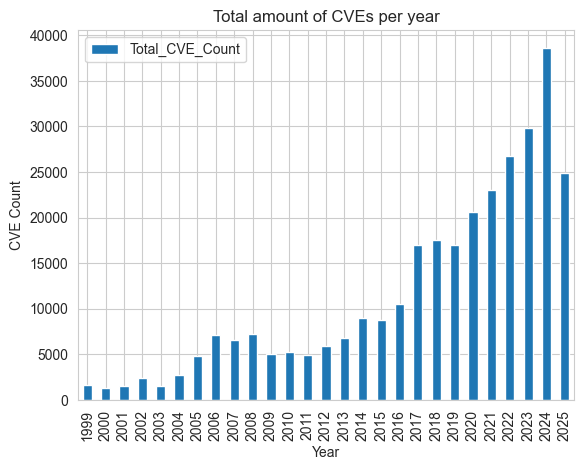

In [110]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df
df.plot(x='Year', y='Total_CVE_Count', kind='bar')
plt.title('Total amount of CVEs per year')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()


something to also note is the severity of each CVEs. CVEs with higher scores in their severity ranking are considered much more dangerous and there is more effort to address those reports.

Overall the severity is important to analyze, but its also important to see how many reports of each severity happened each year. Overall CVEs were usually listed as Medium severity, with High severity following not too far behind. Very rarely were CVEs ranked as low.

It was noticed that in the recent years, severity scores along with impact and expolitability scores were left blank. The following chart visualizes the amount of CVEs each year that have an empty field for severity. This likely reason is that the NVD scoring is being outsourced and it may be possible that they arr not reporting Severity in a different JSON output that the graph is not equipped to handle.

In [ ]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, n.ucobaseSeverity as Severity
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count,Severity
0,59373,HIGH
1,109893,MEDIUM
2,19930,LOW
3,119101,


These severity values can be compared to the year of the CVE to find trends with the CVE data. Below shows a bargraph that displays the severity of CVE nodes for each year.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


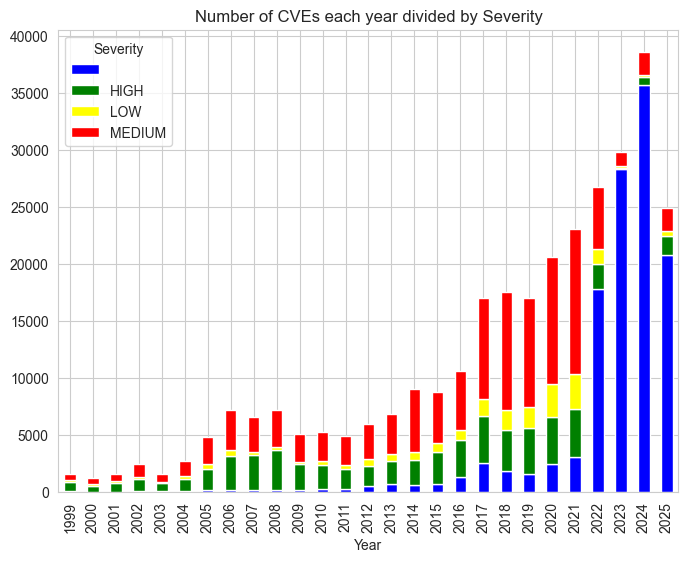

In [ ]:
#makes a more detailed bar graph showing the amount of severity counts each year
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Severity', values = 'Total_CVE_Count')
pivot

colors = ['Blue', 'Green', 'Yellow', 'Red']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by Severity')
plt.show()

The severity ranking is calculated using two other properties: UcoImpact and UcoExpolitability. UcoImpact presents how severe the consequences of the vulnerability, if expolited, would be. UcoExpolitability displays how easy it would be for an attacker to exploit the CVE. Below shows the counts of each ranking for both Impact and Expolitability and what their rankings mean. 

In [ ]:
query = """
MATCH (n:UcoCVE)
RETURN n.ucoimpactScore AS ImpactScore, count(*) AS Count
ORDER BY ImpactScore DESC
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,ImpactScore,Count
0,9.5,49
1,9.2,496
2,8.5,404
3,7.8,256
4,6.9,7409
5,6.4,60062
6,4.9,9652
7,2.9,79793
8,10.0,31053
9,0.0,22


| **Impact Score Range** | **Severity Category** | **Representative Scores in Data** | **Total Count** |
| ---------------------- | --------------------- | --------------------------------- | --------------- |
| 9.0 – 10.0             | Critical Impact       | 10.0, 9.5, 9.2                    | 31,598          |
| 6.0 – 8.9              | High Impact           | 8.5, 7.8, 6.9, 6.4                | 68,131          |
| 4.0 – 5.9              | Moderate Impact       | 4.9                               | 9,652           |
| 1.0 – 3.9              | Low Impact            | 2.9                               | 79,793          |
| 0.0                    | No Impact             | 0.0                               | 22              |
| *(Missing)*            | Unknown               | `[]`                              | 119,101         |


In [ ]:
query = """
MATCH (n:UcoCVE)
RETURN n.ucoexploitabilityScore AS ExploitabilityScore, count(*) AS Count
ORDER BY ExploitabilityScore
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,ExploitabilityScore,Count
0,,119101
1,1.2,13
2,1.5,123
3,1.9,663
4,10.0,67035
5,2.0,4
6,2.2,5
7,2.5,113
8,2.7,161
9,3.1,756


| **Exploitability Score Range** | **Severity Category** | **Representative Scores in Data**         | **Total Count** |
| ------------------------------ | --------------------- | ----------------------------------------- | --------------- |
| `9.0 – 10.0`                   | Very Easy to Exploit  | 10.0, 8.6, 8.0                            | 142,885         |
| `6.0 – 8.9`                    | Easy to Exploit       | 6.8, 6.5, 6.4                             | 11,940          |
| `4.0 – 5.9`                    | Moderate Effort       | 5.5, 5.1, 4.9, 4.4, 4.1                   | 6,898           |
| `1.0 – 3.9`                    | Hard to Exploit       | 3.9, 3.4, 3.2, 3.1, 2.7, 2.5, 2.2, 2.0... | 27,473          |
| `0.0`                          | Not Exploitable       | 0.0                                       | 0 (not shown)   |
| *(Missing)*                    | Unknown               | `[]`                                      | 119,101         |

One of the more important properties is ObtainAllPrivilege. This property allows for an attacker to gain full administrator access to a device or an application. Its important to see if these types of vulnerabilities are becoming more common

Something unusual is that the number of CVEs that allowed for full administrator access has actually increased. The year where the most of theses types of vulnerabilities were reported was in 2007, with 998 total vulnerabilities allowing for admin access. The most recent reports of these types of vulnerabilities was in 2022. Since then there has not been a reported instance of a vulnerability allowing full privilege access. 


In [ ]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, n.ucoobtainAllPrivilege as Access
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   Total_CVE_Count Access
0           303072  false
1             5225   true


| **ObtainAllPrivilege** | **Meaning**                                                                                       | **Count** |
| ---------------------- | ------------------------------------------------------------------------------------------------- | --------- |
| `false`                | The vulnerability **does not** allow an attacker to gain **all system privileges**                | 303,072   |
| `true`                 | The vulnerability **does** allow an attacker to obtain **complete privileges** (e.g., root/admin) | 5,225     |

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


    Total_CVE_Count  Year Access
0              1136  1999  false
1               443  1999   true
2               314  2000   true
3               928  2000  false
4              1257  2001  false
5               299  2001   true
6              2080  2002  false
7               313  2002   true
8              1322  2003  false
9               233  2003   true
10              434  2004   true
11             2273  2004  false
12             4515  2005  false
13              254  2005   true
14             6637  2006  false
15              506  2006   true
16              998  2007   true
17             5582  2007  false
18              736  2008   true
19             6441  2008  false
20             4769  2009  false
21              280  2009   true
22             5094  2010  false
23              150  2010   true
24             4873  2011  false
25               13  2011   true
26             5920  2012  false
27               17  2012   true
28             6810  2013  false
29        

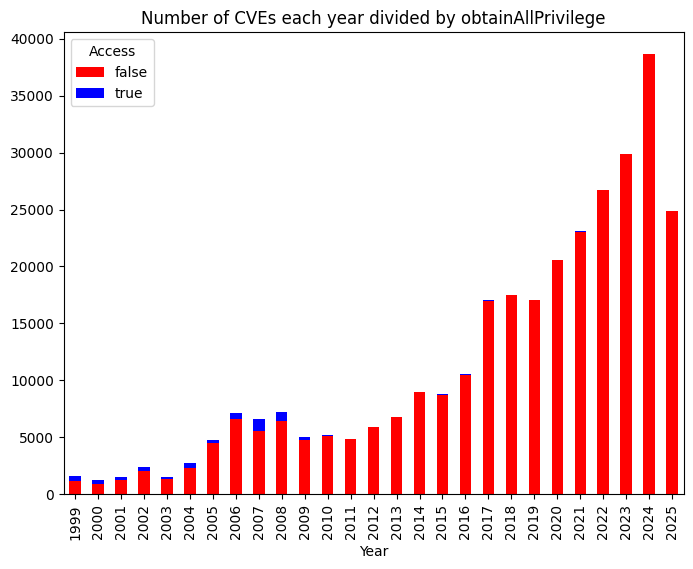

In [ ]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucoobtainAllPrivilege as Access
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Access', values = 'Total_CVE_Count')
print(pivot)

colors = ['Red', 'Blue']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by obtainAllPrivilege')
plt.show()

Another important factor that CVEs list is if the vulnerability requires action from the affecter user before an attack can expolit it. Vulnerabilities that do not have this requirement are far more dangerous as it removes a barrier that attackers must break before they can expolit. The query below finds the amount of CVEs each year divided based on user interaction.

A disturbing trend is seen here as the amount of vulnerabilities that are able to expolit without user interaction have been increasing.

In [ ]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, n.ucouserInteractionRequired as Interaction
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count,Interaction
0,253184,false
1,55113,true


| **Interaction Required** | **Meaning**                                                                                      | **Count** |
| ------------------------ | ------------------------------------------------------------------------------------------------ | --------- |
| `false`                  | **No user action is needed** — the exploit can be triggered automatically                        | 253,184   |
| `true`                   | **User action is required** — the attacker needs the victim to interact (e.g., click, open file) | 55,113    |

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Interaction    false    true
Year                        
1999          1531.0    48.0
2000          1200.0    42.0
2001          1531.0    25.0
2002          2331.0    62.0
2003          1478.0    77.0
2004          2600.0   107.0
2005          4537.0   232.0
2006          6481.0   662.0
2007          5196.0  1384.0
2008          5247.0  1930.0
2009          3330.0  1719.0
2010          3363.0  1881.0
2011          3276.0  1610.0
2012          4237.0  1700.0
2013          5170.0  1649.0
2014          5517.0  3482.0
2015          6150.0  2616.0
2016          7170.0  3390.0
2017         11115.0  5908.0
2018         11541.0  5954.0
2019         11949.0  5085.0
2020         14687.0  5920.0
2021         16307.0  6769.0
2022         23862.0  2861.0
2023         29854.0     NaN
2024         38639.0     NaN
2025         24885.0     NaN


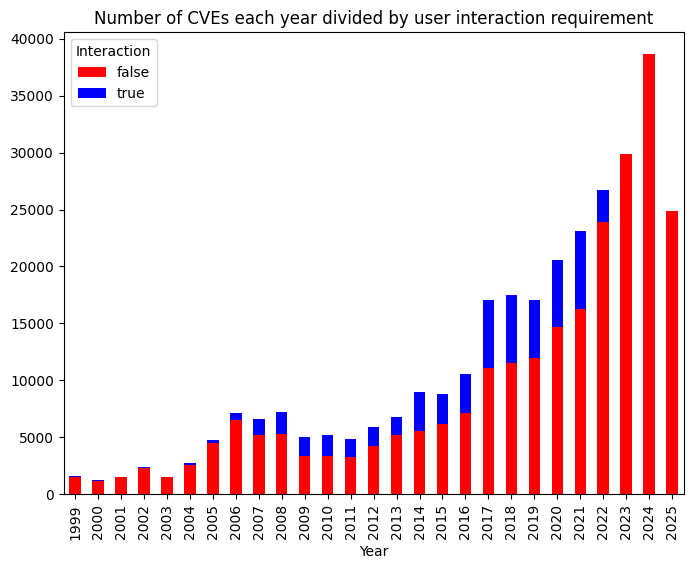

In [ ]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucouserInteractionRequired as Interaction
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Interaction', values = 'Total_CVE_Count')
print(pivot)

colors = ['Red', 'Blue']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by user interaction requirement')
plt.show()

The status of the CVE is recorded in the property ucovulnStatus. This property records the current state of the CVE as these reports must be recieved, reviewed, and validated. Below divides the CVEs by their current status and further explain what each rank means

In [ ]:
query = """
MATCH (n:UcoCVE)
RETURN n.ucovulnStatus AS Status, count(*) AS Count
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Status,Count
0,Deferred,94588
1,Analyzed,36137
2,Modified,135261
3,Awaiting Analysis,25848
4,Rejected,15794
5,Undergoing Analysis,491
6,Received,178


| **Status**            | **Count** | **Meaning**                                                            |
| --------------------- | --------- | ---------------------------------------------------------------------- |
| `Modified`            | 135,261   | The CVE has been reviewed and updated, usually with improved metadata. |
| `Deferred`            | 94,588    | The CVE has been postponed or withheld from public disclosure.         |
| `Analyzed`            | 36,137    | The CVE has been reviewed and validated by analysts.                   |
| `Rejected`            | 15,794    | The CVE ID was issued but later ruled invalid.                         |
| `Awaiting Analysis`   | 25,848    | The report was received but not yet reviewed by analysts.              |
| `Undergoing Analysis` | 491       | The CVE is currently being assessed before publication.                |
| `Received`            | 178       | The CVE was submitted and is waiting in the queue for triage.          |

# CVE Relationships

CVEs are related to three different nodes: UcoexCPE, UcoexObservedExample and UcoVulnerability. UcoVulnerability nodes contain descriptions about the affected CVE and CPE gives information about the affected application or product. UcoexObservedExample displays any notable examples of the vulnerability being expolited. These relationships are vital as they can help display complex connections and trends seen with vulnerabilities.

Below shows the relationships to and from CVE and the total counts

In [ ]:
query = """
MATCH (n:UcoCVE) -[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n)-[r]->(m:UcoCVE)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoCVE,UCOEXHASCPE,UcoexCPE,663925
1,UcoVulnerability,UCOHASCVE_ID,UcoCVE,308297
2,UcoexObservedExample,UCOEXEXAMPLEOBSERVEDIN,UcoCVE,3011


|     Source Node     |      Relationship      | Direction | Target Node | Count |
|---------------------|------------------------|-----------|-------------|-------|
| UcoCVE              | UCOEXHASCPE            | Outgoing  | UcoexCPE    | 663925|
| UcoVulnerability    | UCOHASCVE_ID           | Incoming  | UcoCVE      | 308297|
| UcoexObservedExample| UCOEXEXAMPLEOBSERVEDIN | Incoming  | UcoCVE      |   3011|
| UcoCVE              | (all)                  | Undirected| Mixed       | 975233|

# CPEs

CPEs are nodes that describe what the vulnerability affects. This includes information about the affected publisher, the product, and other important information. This information can be analyzed to see what types of vulnerabilities are affected which publishers and products.

First, CPEs must be analyzed by themselves before being observed with CVEs. First a count is gather of the amount of CPE nodes that are present in the knowledge graph.

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CPE_count
0,138459


# CPE Properties

CPE properties contain important information about the affect product and more. CPE nodes contain far less properties than CVEs, but they still contain valuable information.

The most important property of CPE nodes is the label. The label is a string that is divided to present important information about the node. The string is formatted as follows:

CPE:2.3:(part):(publisher):(product):(version):(update):(edition):(language):(sw_edition):(target software):(target hardware):(other)

Previous workbook reports on CPE nodes have analyzed the publishers and the products that are listed in these labels. One of the more important pieces of this string is the part. The part is a single character that describe what exactly was affected in the CPE. The key for this is:

a - application/
o - operating system/
h - hardware

Considering that the part shows exactly was was affected, the CPEs can be analyzed to see how many affected each of the three parts.

As expressed in the graph below, the majority of CPEs were affecting applications. Operating systems were also not too far behind. Hardware was consider rather rare to be affected having barely a thousand entries.


C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CPE_count Part
0            80386    a
1            56343    o
2             1730    h


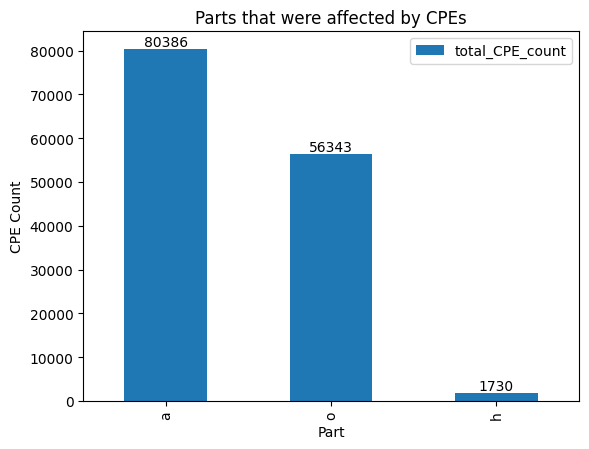

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[2] as Part
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

ax = df.plot(x='Part', y='total_CPE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Parts that were affected by CPEs')
plt.xlabel('Part')
plt.ylabel('CPE Count')
plt.show()

Taking this data some important questions can be asked. For example, how many CPEs affect each of the three parts each year? To grab the year the lastModified property was obtained to grab when the CPE was last updated. This date may not be the day the CPE was created, but rather references the last time it was updated. This is likely why there are no entries for CPEs between 1999-2006.

The graph shows that for each year, applications contained the majority of the CPEs for that year. However, starting at 2020, there was a rapid increase in CPEs that affected operating systems that the amount became higher than the CPEs affecting applications. This is especially seen in 2023, with over 11 thousand CPEs affecting operating systems. This data likely shows a shift in what parts attackers are targeting, with more of a focus being placed on operating systems rather than applications

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part  Application  Hardware  Operating System
Year                                         
2007        753.0      60.0             225.0
2008        659.0      61.0             176.0
2009        175.0       2.0              28.0
2010        505.0       1.0              71.0
2011        299.0       7.0              87.0
2012       1531.0      31.0             111.0
2013       1040.0      55.0             111.0
2014       2183.0      29.0             103.0
2015        796.0      32.0             182.0
2016        632.0      52.0             153.0
2017        408.0       1.0             105.0
2018        661.0      10.0             174.0
2019       3892.0      12.0            1090.0
2020       3833.0      35.0            4111.0
2021       3317.0     142.0            7448.0
2022       2355.0      17.0            4341.0
2023       3335.0      72.0           11710.0
2024       1105.0      15.0            1148.0
2025       1119.0       NaN             694.0


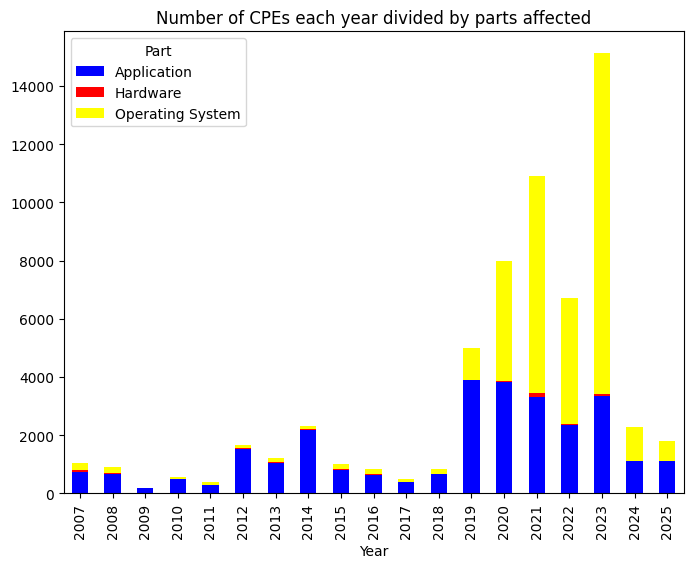

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[2] as Part, split(toString(n.lastModified), '-')[0] as Year
ORDER BY Year DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CPE_count')
names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
pivot = pivot.rename(columns=names)
print(pivot)

colors = ['Blue', 'Red', 'Yellow',]

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CPEs each year divided by parts affected')
plt.show()

The CPEName also specifies the affected publishers. The publishers are the companies responsible for the products affected by vulnerabilities. Below shows the top publishers with the most related CPEs. Only the 15 most affected publishers are listed.

The affected publishers are usually names that are relatively familiar: HP, Intel, Microsoft, and Dell are just a few examples. However it also includes publishers may not be attributed to these big names and sometimes only have a few instances of vulnerabilities overall.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


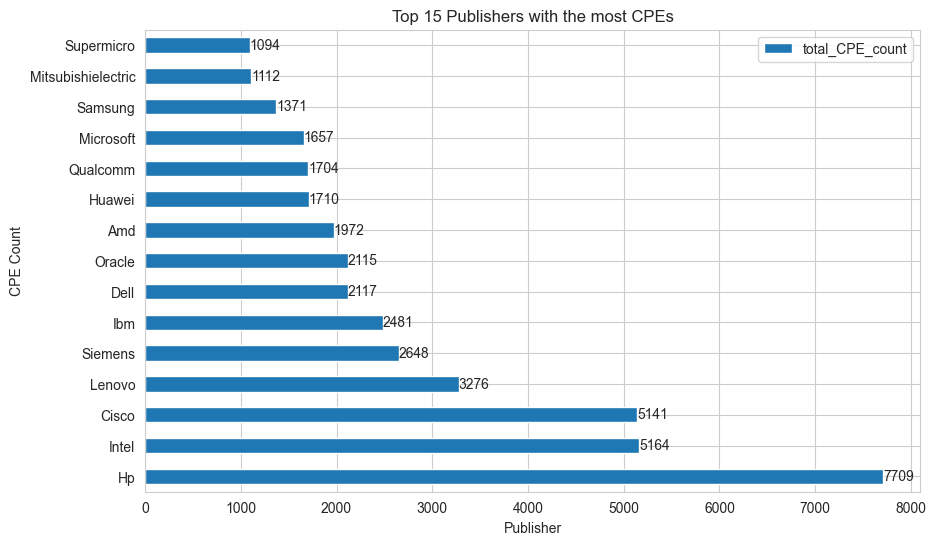

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, apoc.text.capitalize(split(n.cpeName, ':')[3]) as Publisher
ORDER BY total_CPE_count DESC
LIMIT 15
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


ax = df.plot(x='Publisher', y='total_CPE_count', kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Top 15 Publishers with the most CPEs')
plt.xlabel('Publisher')
plt.ylabel('CPE Count')
plt.show()


The CPEName next shows the exact product that was affected. The products are the exact application that was affected by the vulnerability. The following shows the top 15 products that were affected by the most CPEs

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


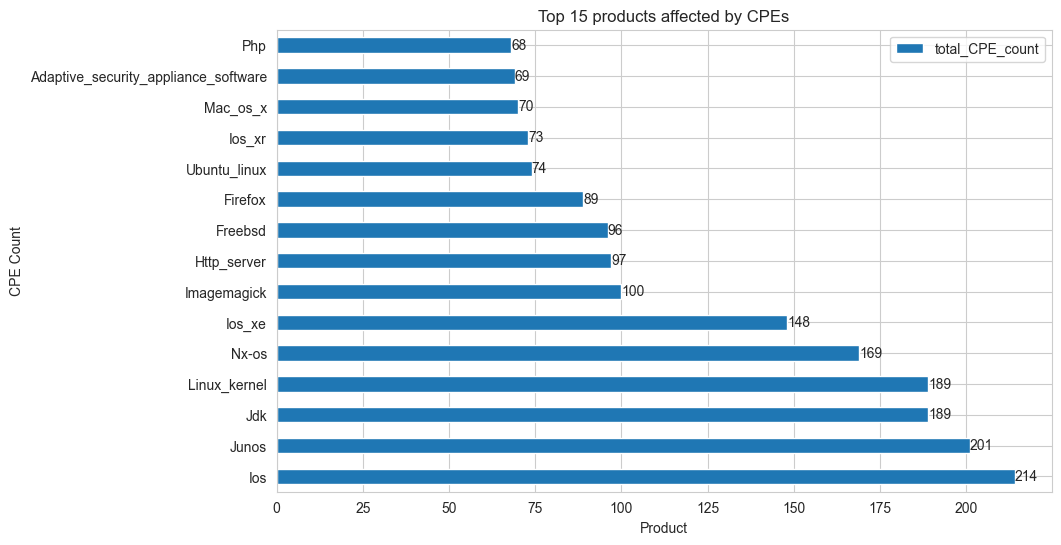

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, apoc.text.capitalize(split(n.cpeName, ':')[4]) as Product
ORDER BY total_CPE_count DESC
LIMIT 15
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Product', y='total_CPE_count', kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Top 15 products affected by CPEs')
plt.xlabel('Product')
plt.ylabel('CPE Count')
plt.show()


Oftentimes CPEs only affect a specific version of a product. The version can usually be an older version of a product or a new one. However, somethimes a CPE either does not affect a specific version or does not list it.

CPEName lists the version if the CPE only affected one version of a product. Below shows How many CPEs were specific to one version of a product

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


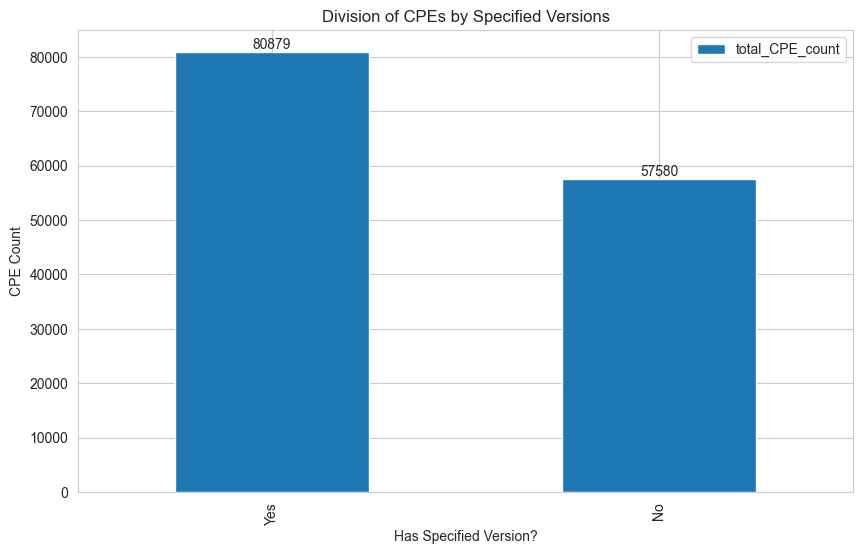

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, 
CASE
    WHEN split(n.cpeName, ':')[5] = '*' THEN 'No'
    ELSE 'Yes'
END AS Has_Specified_Version
ORDER BY total_CPE_count DESC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Has_Specified_Version', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CPEs by Specified Versions')
plt.xlabel('Has Specified Version?')
plt.ylabel('CPE Count')
plt.show()

The next item listed in CPEName is update. The update shows if the CPE affected a specific patch or update of the product, such as a beta version of a product for example. Below divides the CPEs by update

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


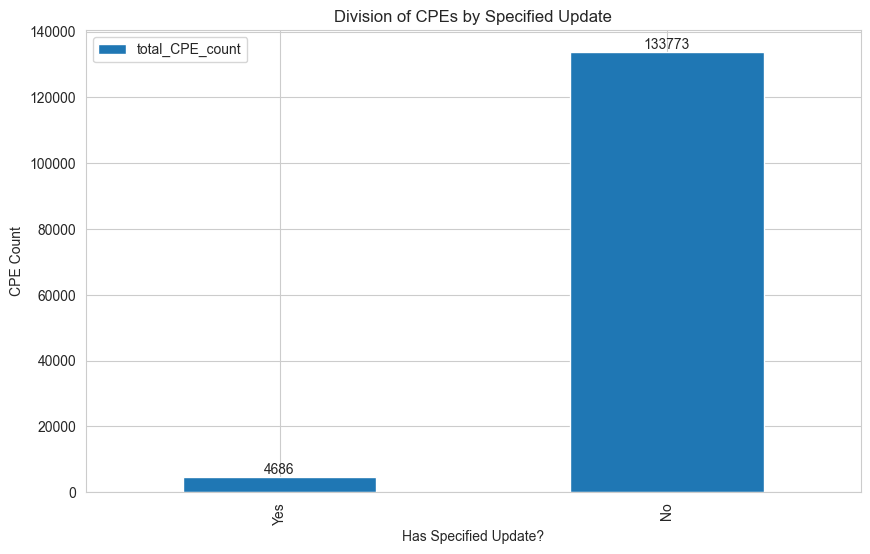

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, 
CASE
    WHEN split(n.cpeName, ':')[6] = '*' THEN 'No'
    ELSE 'Yes'
END AS Has_Specified_Update
ORDER BY total_CPE_count ASC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Has_Specified_Update', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CPEs by Specified Update')
plt.xlabel('Has Specified Update?')
plt.ylabel('CPE Count')
plt.show()

Next listed is the edition. The edition specifies a version of the product that usually is specified for specific hardware or applications. THis property can be useful in slowing if the product is related to any other important parts that might in turn also be affected. Below shows how many CPEs are specific to an edition.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


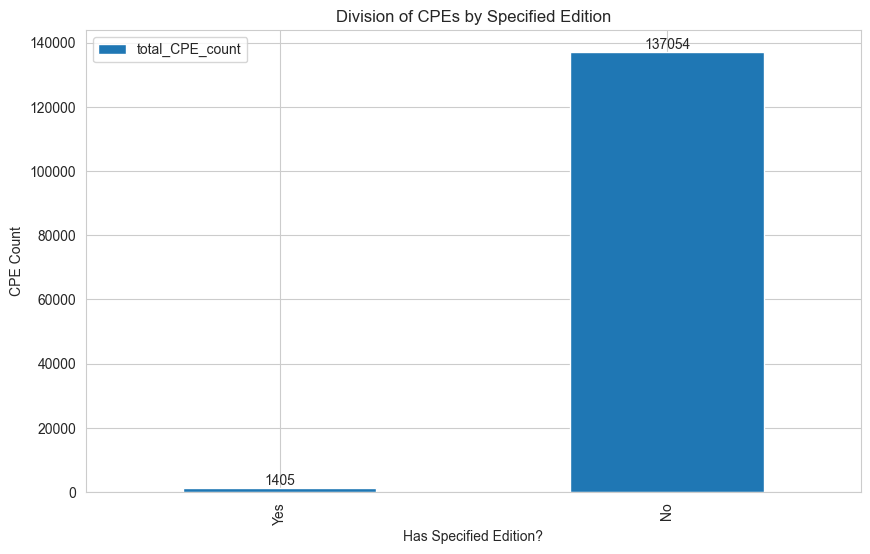

In [ ]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, 
CASE
    WHEN split(n.cpeName, ':')[7] = '*' THEN 'No'
    ELSE 'Yes'
END AS Has_Specified_Edition
ORDER BY total_CPE_count ASC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Has_Specified_Edition', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CPEs by Specified Edition')
plt.xlabel('Has Specified Edition?')
plt.ylabel('CPE Count')
plt.show()

One other property is of importance. The dictionary_found property displays if the CPE is found in the local CPE dictionary database. Its a boolean value thats set to true if it exists and false if it does not. Below displays the distribution of CPEs based on this boolean value.

   total_CPE_count  Exists_in_Dictionary
0            77159                 False
1            61300                  True


C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


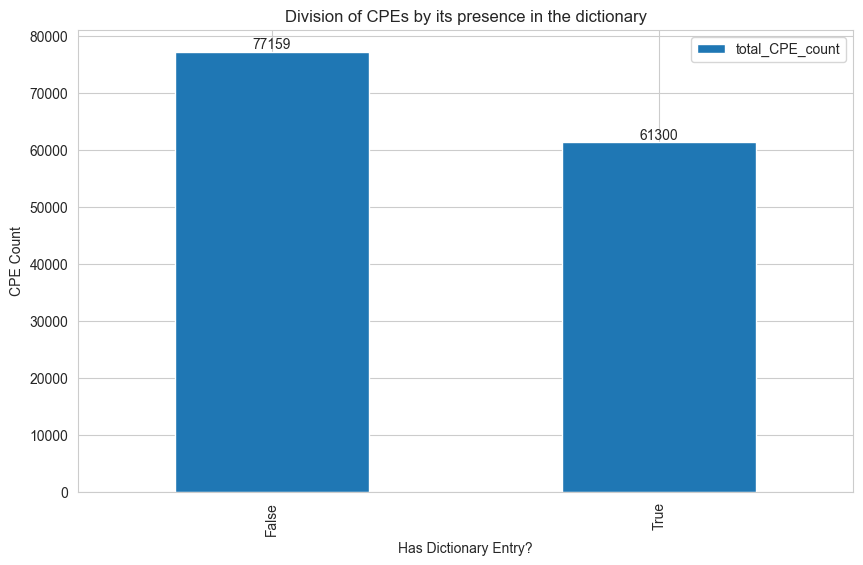

In [113]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, n.dictionary_found as Exists_in_Dictionary
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

ax = df.plot(x='Exists_in_Dictionary', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CPEs by its presence in the dictionary')
plt.xlabel('Has Dictionary Entry?')
plt.ylabel('CPE Count')
plt.show()

# CPEs Relationships

CPEs are only related to one node. CPEs are connected to CVEs through the relationship UCOEXHASCPE. A single CPE can have multiple CVEs connected to it. However some CVEs are not connected to any CPEs at all, however this is likely due to delays in the connection.

Taking the previous information that was gathered through individual analysis on CPEs, this can then be combined with CVEs to further tie it to vulnerabilities.

Taking the fact that CPEs can have several CVEs connected to them through this relationship, there should be a count showing how many CVEs are connected to applications, hardware, or operating systems. This then can also be divided by year to further develop the CVEs

THis further shows that attacks related to operating systems have been increasing. Hardware related CVEs aren't really seen showing that barely any CVEs are not really related to hardware CPEs and that these are still extremely rare. This can help show which parts are more of the target and where security measures likely need to focus on.

In [114]:
query = """
MATCH (n:UcoexCPE) <-[r]-(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoexCPE,UCOEXHASCPE,UcoCVE,663925


|     Source Node     |      Relationship      | Direction | Target Node | Count |
|---------------------|------------------------|-----------|-------------|-------|
| UcoexCPE            | UCOEXHASCPE            | Incoming  | UcoCVE      | 663925|


Using the relationships between nodes, connections can be made between the properties of each type of node to reveal hidden trends and answer possible questions.

For example, lets say someone wanted to know the division of parts affected by CVEs each year but also want to know what parts were affected the most by the CPEs related to them. By analyzing the properties through the relationship, this question can be answered like below. As the graph reveals, in recent years CVEs affecting operating systems have seen a rapid increase.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part  Application  Hardware  Operating System
Year                                         
1999        743.0      53.0             732.0
2000        922.0      37.0             320.0
2001       1166.0      75.0             381.0
2002       1937.0     128.0             414.0
2003       1224.0      42.0             306.0
2004       2282.0     116.0             547.0
2005       4049.0     138.0             596.0
2006       6380.0     167.0             602.0
2007       5624.0     236.0             934.0
2008       6418.0     196.0             794.0
2009       4691.0     151.0             792.0
2010       5621.0     110.0            1150.0
2011       5137.0      65.0            1069.0
2012       6370.0     134.0            1220.0
2013       7333.0     181.0            2237.0
2014       8421.0      90.0            3636.0
2015       7885.0      89.0            6430.0
2016       9332.0     238.0            7077.0
2017      12470.0      30.0           14965.0
2018      14584.0     145.0       

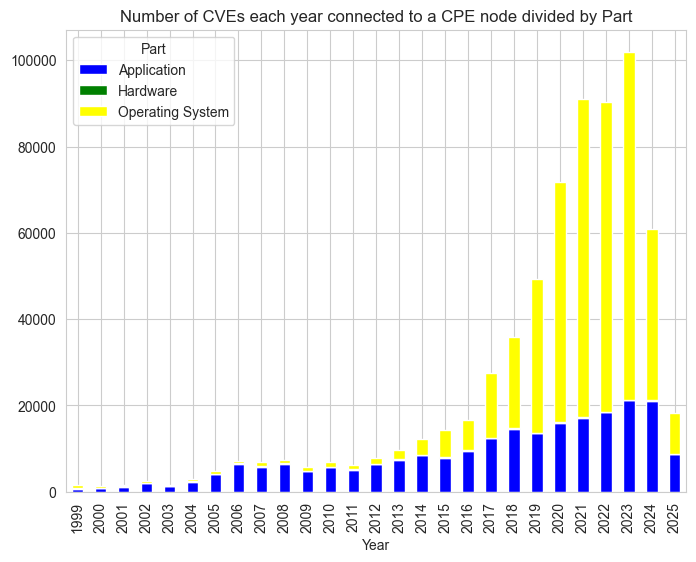

In [115]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
RETURN COUNT(n) as total_CVE_count,split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CVE_count')
names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
pivot = pivot.rename(columns=names)
print(pivot)

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year connected to a CPE node divided by Part')
plt.show()

Using this chart other questions can be asked. For example, considering that operating system CVEs seem to be more common in recent years, what are their severity rankings. This question can allow for specification of what property values we are wanting and reveal hidden connections between specific pieces of data. Percentages can also be derived from the data to form other types of charts to display results differently.

An important note is that the results here are off due to the previous mentioned issue with the severity ranking.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Severity            HIGH     LOW  MEDIUM
Year                                    
1999         NaN   408.0    86.0   220.0
2000         NaN   159.0    47.0   110.0
2001         NaN   166.0    82.0   125.0
2002         NaN   180.0    63.0   157.0
2003         NaN   153.0    35.0   113.0
2004         NaN   248.0    99.0   186.0
2005         NaN   201.0   145.0   215.0
2006         NaN   196.0    96.0   255.0
2007         NaN   373.0    66.0   340.0
2008         NaN   325.0    43.0   278.0
2009         NaN   263.0    37.0   278.0
2010         NaN   309.0    83.0   343.0
2011         NaN   295.0    90.0   362.0
2012         NaN   352.0   111.0   422.0
2013         NaN   504.0   150.0   873.0
2014         3.0   667.0   173.0   900.0
2015         1.0  1113.0   239.0  1388.0
2016         5.0  1616.0   310.0  1532.0
2017       107.0  1865.0   501.0  2620.0
2018       123.0  1631.0   515.0  2816.0
2019        17.0  1825.0   734.0  3000.0
2020       137.0  1660.0  1034.0  3565.0
2021       993.0

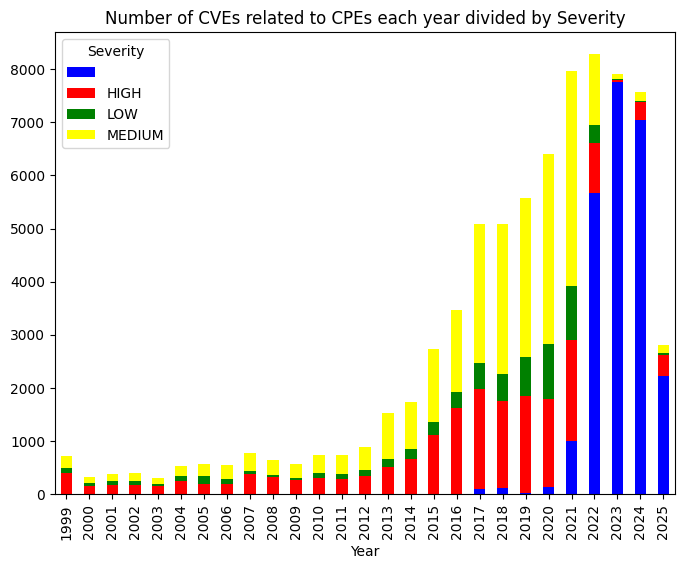

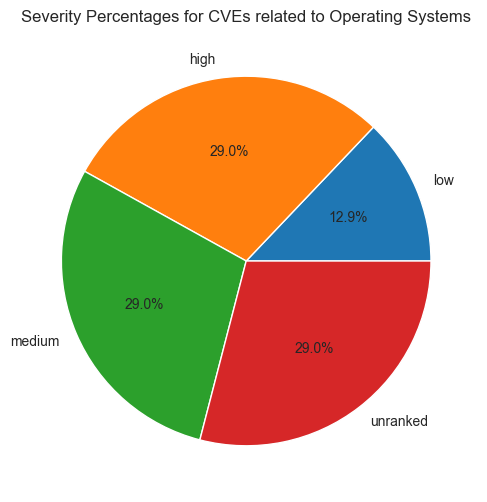

In [ ]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE split(c.cpeName, ':')[2] = 'o'
RETURN COUNT(DISTINCT n) as total_CVE_count,split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity
ORDER BY split(n.label, '-')[1] ASC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Severity', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Green', 'Yellow']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs related to CPEs each year divided by Severity')
plt.show()

Severity_count = df['Severity'].value_counts().sort_values(ascending=True)

sb.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(Severity_count, labels=['low', 'high', 'medium', 'unranked'], autopct='%1.1f%%')
plt.title('Severity Percentages for CVEs related to Operating Systems')
plt.show()

Another question that can be asked is which CPE parts are more connected to CVEs that allow for full administrator access.

The graph shows that CVEs that allow for full administrator access were more tied to applications rather than operating systems. 2021 is a bit of an outlier as the majority of CVEx that cause full admin access did target operating systems. However for the majority of years, Applications were the main target. This shows that applications are likely more vulnerable to full access.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part      a     h      o
Year                    
1999  162.0   8.0  315.0
2000  194.0   8.0  134.0
2001  205.0   3.0  113.0
2002  230.0  17.0   92.0
2003  164.0   5.0   83.0
2004  355.0  13.0  159.0
2005  177.0   2.0   81.0
2006  402.0  23.0  111.0
2007  774.0  43.0  314.0
2008  624.0  39.0  170.0
2009  284.0  13.0   86.0
2010  209.0   3.0   77.0
2011   16.0   1.0    6.0
2012   16.0   2.0    NaN
2013    4.0   3.0    2.0
2014   32.0   2.0    8.0
2015   22.0   2.0   44.0
2016   45.0   5.0   33.0
2017   28.0   NaN   58.0
2018   18.0   NaN    4.0
2019    1.0   NaN    1.0
2020    2.0   NaN    1.0
2021    4.0   NaN  263.0
2022    2.0   NaN    NaN


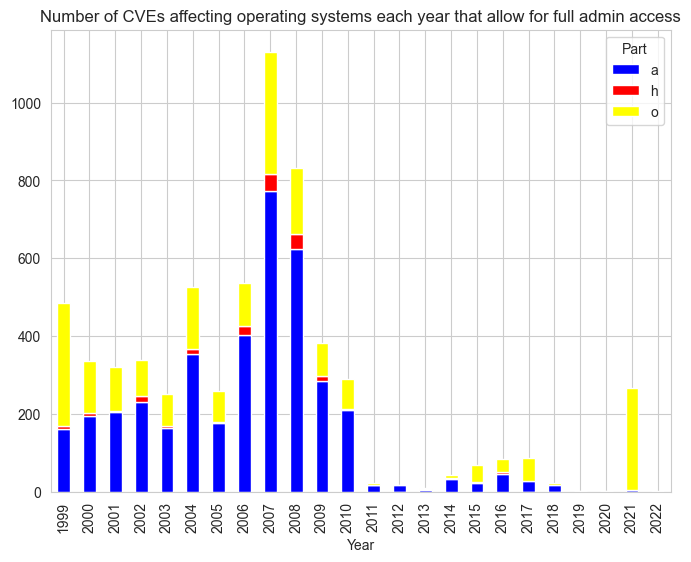

In [ ]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucoobtainAllPrivilege = 'true'
RETURN COUNT(n) as total_CVE_count, split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Yellow']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs affecting operating systems each year that allow for full admin access')
plt.show()

In [ ]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucoobtainAllPrivilege = 'true'
RETURN COUNT(n) as total_CVE_count, split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""

# CWEs

CWE nodes discuss common weaknesses that can be found. The amount of CWEs is far less than other nodes in the knowledge graph but are equally as important and contain vital information. This is because sometimes CVEs are tied to specific weaknesses and can help further explain how the vulnerability occured.

Before comparing CWEs to other nodes, CWEs themselves must be understood. Firstly its important to see how many CWEs are present in the knowledge graph

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count
0,969


# CWE Properties

CWEs contain quiet a few different properties that are used to describe the weakness and possible solutions. Firstly theres the ucoAbstraction property. This property describes how much is known about the weakness and how descriptive the CWE is. This information is useful as the more that is known about the weakness, the more that can be done to prevent it.

Shown below most CWEs fall into the variant and base categories. These categories contain the most information about the weakness while other categories such as pillar are more generic and have less detail.

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, n.ucoabstraction as Abstraction
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,Abstraction
0,299,Variant
1,540,Base
2,113,Class
3,7,Compound
4,10,Pillar


CWEs also contain a property, ucoApplicablePlatform that displays the language and, if applicable, operating system. The following query will take all of the weakness and display the language they affect.

An important note is that some weaknesses affect multiple languages, but the first listed one was recorded

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, SPLIT(n.ucoapplicablePlatform, '"')[3] as Language
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,Language
0,530,Not Language-Specific
1,231,None
2,91,C
3,53,Java
4,12,PHP
5,9,Verilog
6,7,C++
7,6,Not Technology-Specific
8,5,ASP.NET
9,4,SQL


The same property may also show if the weakness is tied to a specific technology or operating system. The string can be further broken down to show which technologies or operating systems it affects. 

Note that not all CWEs have this listed in the property.

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count,
CASE
    WHEN n.ucoapplicablePlatform CONTAINS "Operating_System" THEN SPLIT(SUBSTRING(n.ucoapplicablePlatform, apoc.text.indexOf(n.ucoapplicablePlatform, "Operating_System")), '"')[3]
    WHEN n.ucoapplicablePlatform CONTAINS "Technology" THEN SPLIT(SUBSTRING(n.ucoapplicablePlatform, apoc.text.indexOf(n.ucoapplicablePlatform, "Technology")), '"')[3]
END AS Affected_System
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,Affected_System
0,714,None
1,113,Not OS-Specific
2,30,Not Technology-Specific
3,18,Mobile
4,15,ICS\/OT
5,14,AI\/ML
6,13,Web Based
7,12,Windows
8,11,Web Server
9,9,System on Chip


The commonConsequences property describes what usually happens when the weakness is expolited. Its structured the same way as the applicablePlatform property

Note that some CWEs cause multiple consequences but only the first listed consequence is listed

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count,
CASE
    WHEN n.ucocommonConsequences CONTAINS "Impact" THEN SPLIT(SUBSTRING(n.ucocommonConsequences, apoc.text.indexOf(n.ucocommonConsequences, "Impact")), '"')[2]
END AS Consequence
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,Consequence
0,125,Read Application Data
1,89,Bypass Protection Mechanism
2,80,Unexpected State
3,68,Gain Privileges or Assume Identity
4,66,Varies by Context
5,55,Read Files or Directories
6,48,Modify Memory
7,47,Execute Unauthorized Code or Commands
8,46,None
9,45,Read Memory


ucoMappingNotes is another JSON property that is slightly simplier than the other properties. This property mainly describes using mapping for this CWE is allowed and the explaination for why and why not. The query below divides the CWEs to show which ones allow for mapping

As seen below, most CWEs do allow for mapping to occur, though 88 entries to require review before it can occur. In total, 128 CWE nodes either discourage the usage of mapping or outright not allow for mapping to occur.

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, SPLIT(SUBSTRING(n.ucomappingNotes, 7), ',')[0] as Is_mapping_allowed
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,Is_mapping_allowed
0,753,Allowed
1,88,Allowed-with-Review
2,84,Prohibited
3,44,Discouraged


To combat these CWEs, mitigations are constantly being proposed and tested. The current phases of implementing mitigations are recorded in the property ucomodesOfIntroduction, which is also stored in a string



In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, SPLIT(n.ucomodesOfIntroduction, '"')[3] as Introduction_Method
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,Introduction_Method
0,489,Implementation
1,319,Architecture and Design
2,138,None
3,12,Operation
4,4,Requirements
5,2,Build and Compilation
6,1,Testing
7,1,Manufacturing
8,1,Integration
9,1,System Configuration


ucoStructure is a property that lists the structure of the mitigation to combat the weakness

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, n.ucostructure as structure
ORDER BY total_CWE_count DESC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,structure
0,962,Simple
1,4,Composite
2,3,Chain


ucostatus displays the current status of the mitigation. This property is useful as it shows the current state of measures being taken to combat weaknesses.

For most CWEs, the current status is either incomplete or in a draft state, though there have been a few that have been able to stabilize the weakness.

In [ ]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, n.ucostatus as current_status
ORDER BY total_CWE_count DESC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,current_status
0,486,Incomplete
1,432,Draft
2,26,Stable
3,25,Deprecated


# CWES, CVEs and CPEs

CVEs and CPEs are not directly connected to CWEs. CWEs however are connected to a node called UcoVulnerability, which does connect to CVEs. Using this information we can see how many CVEs each year were the result of a weakness.

The chain is as follows: UcoCVE <- UCOHASCVE_ID - UcoVulnerability <- UCOHASVULNERABILITY - UcoExpolitTarget - UCOHASWEAKNESS -> UcoCWE

The query below shows the amount of CVEs that are in some way related to a weakness. As shown here, the amount of CVEs that have some relation to a weakness has increased greatly.

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


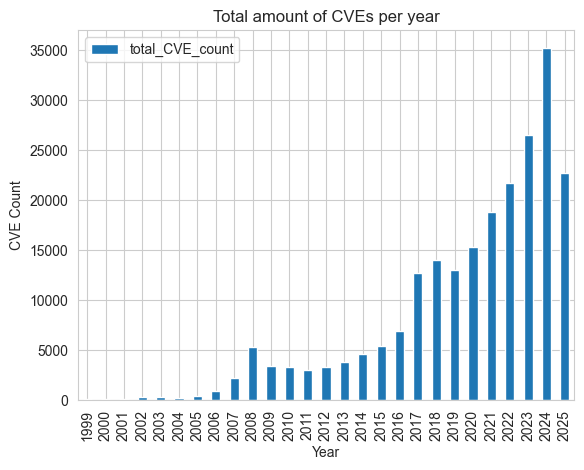

In [ ]:
query = """
MATCH (n:UcoCVE)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
RETURN count(DISTINCT n) as total_CVE_count, split(n.label, '-')[1] as Year
ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

df.plot(x='Year', y='total_CVE_count', kind='bar')
plt.title('Total amount of CVEs per year')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()

Considering that previous examples with CVEs and CPEs have been observing examples, a few questions can be asked to expand the analysis further.
Are Operating System related CVEs more likely to be caused by weaknesses?

The query below displays a graph that shows which CVEs are and are not affected by weaknesses

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CVE_count related_to_weakness
0            57094                 Yes
1            17181                  No


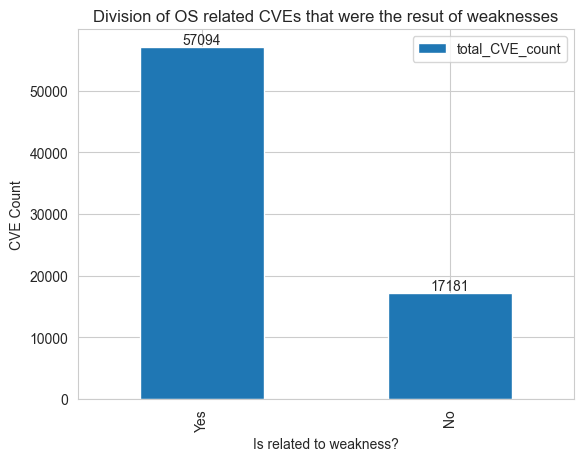

In [ ]:
query = """
MATCH (u:UcoexCPE)<-[UCOEXHASCPE]-(n:UcoCVE)
WHERE split(u.cpeName, ':')[2] = 'o'
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
RETURN count(DISTINCT n) as total_CVE_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_weakness
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

ax = df.plot(x='related_to_weakness', y='total_CVE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of OS related CVEs that were the resut of weaknesses')
plt.xlabel('Is related to weakness?')
plt.ylabel('CVE Count')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Abstraction    Base   Class  Compound  Pillar  Variant
Year                                                  
1999           15.0    21.0       NaN     NaN      NaN
2000            3.0     3.0       NaN     NaN      NaN
2001           14.0     8.0       NaN     NaN      2.0
2002           19.0    22.0       NaN     NaN      1.0
2003           11.0    24.0       NaN     NaN      1.0
2004           27.0    16.0       NaN     NaN      5.0
2005           30.0    28.0       NaN     1.0      3.0
2006           27.0    48.0       1.0     NaN      2.0
2007           80.0   155.0       2.0     NaN      1.0
2008          119.0   215.0       6.0     NaN      3.0
2009          110.0   179.0       2.0     NaN      8.0
2010          142.0   259.0       2.0     1.0     24.0
2011          155.0   255.0       3.0     4.0     26.0
2012          139.0   351.0       7.0     7.0     33.0
2013          224.0   627.0      34.0     5.0     33.0
2014          295.0   645.0      28.0    22.0     42.0
2015      

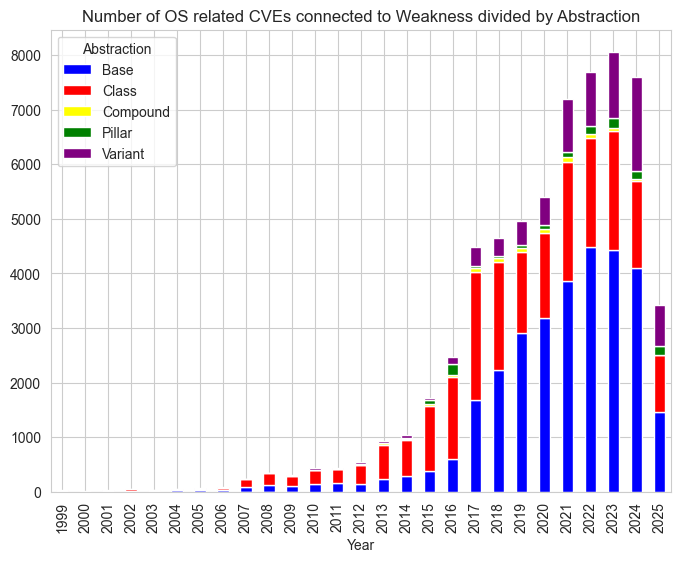

In [ ]:
query = """
MATCH (c:UcoexCPE)<-[UCOEXHASCPE]-(n:UcoCVE)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
WHERE split(c.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT n) as total_CVE_count, split(n.label, '-')[1] as Year, w.ucoabstraction as Abstraction
ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Abstraction', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Yellow', 'Green', 'Purple']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of OS related CVEs connected to Weakness divided by Abstraction')
plt.show()


# CAPEC

CAPEC nodes display attack patterns that are often used when expoliting variables. CAPEC nodes are vital to the knowledge as these nodes serve as a connection between both sides of the knowledge graph.

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(n) as total_CAPEC_count
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CAPEC_count
0,559


   total_CAPEC_count Abstraction
0                317    Detailed
1                181    Standard
2                 61        Meta


C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


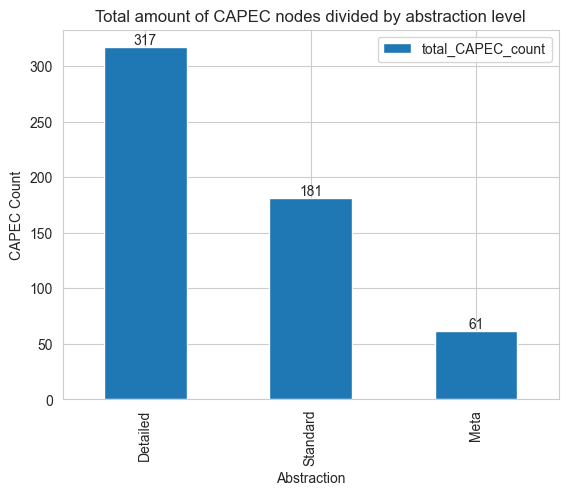

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(n) as total_CAPEC_count, n.ucoexAbstraction as Abstraction
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Abstraction', y='total_CAPEC_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Total amount of CAPEC nodes divided by abstraction level')
plt.xlabel('Abstraction')
plt.ylabel('CAPEC Count')
plt.show()

Often times attack patterns will require a prerequiste to be fufilled in order for the attack to occur. The following query shows which CAPEC nodes contain a prerequisite. 

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


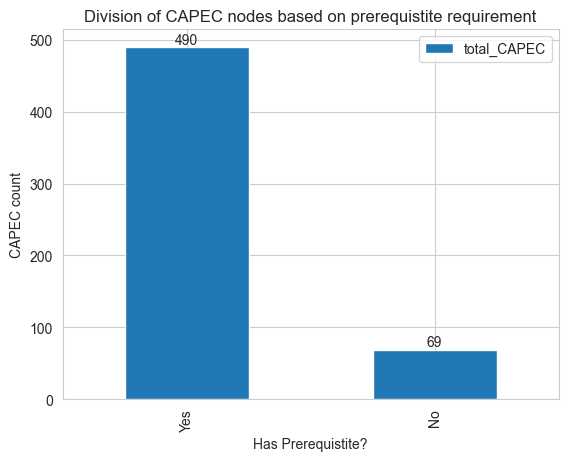

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexPrerequisites IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_prerequisites
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_prerequisites', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on prerequistite requirement')
plt.xlabel('Has Prerequistite?')
plt.ylabel('CAPEC count')
plt.show()

The ucoexMitigations contains a description of the mitigation method for the attack pattern. However a null value can be present if one isnt there. 

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


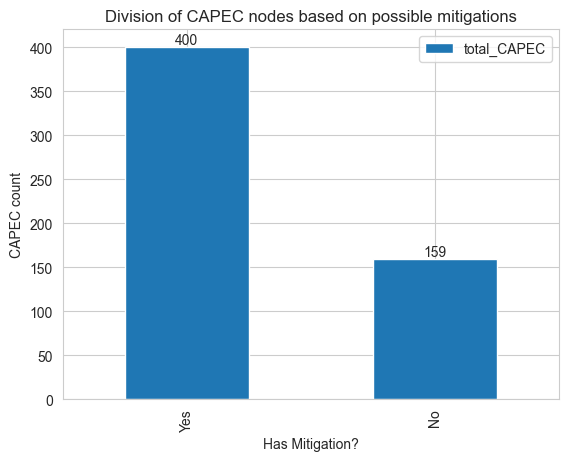

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexMitigations IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_Mitigations
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_Mitigations', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on possible mitigations')
plt.xlabel('Has Mitigation?')
plt.ylabel('CAPEC count')
plt.show()

UcoexExample displays any examples of the attack pattern that occur. The property may have a null value if there are no examples present

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


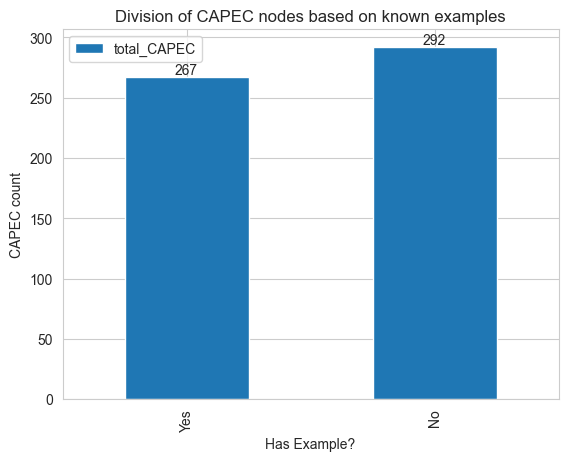

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexExample IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_Examples
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_Examples', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on known examples')
plt.xlabel('Has Example?')
plt.ylabel('CAPEC count')
plt.show()

Oftentimes attack patterns may be related to other attack patterns. Other times they may be unrelated. UcoexRelatedAttPattern displays all of the attack patterns in a list that the attack pattern is related to

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


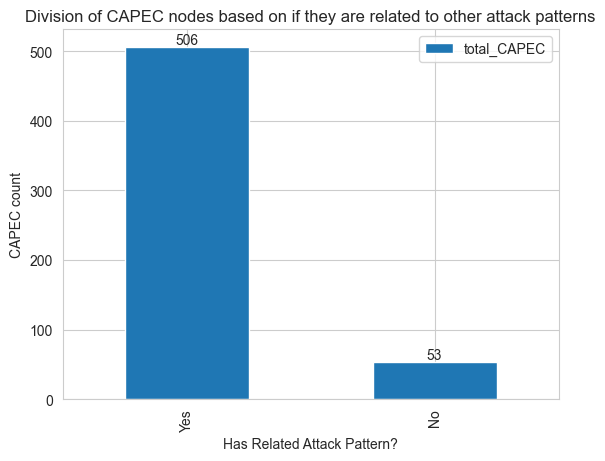

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexRelatedAttPattern IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_RelatedAttackPattern
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_RelatedAttackPattern', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on if they are related to other attack patterns')
plt.xlabel('Has Related Attack Pattern?')
plt.ylabel('CAPEC count')
plt.show()

Attack patterns may also be related to specific weaknesses. UcoexRelatedWeaknesses displays a list of all weaknesses that a CAPEC node is related to but may also be null

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


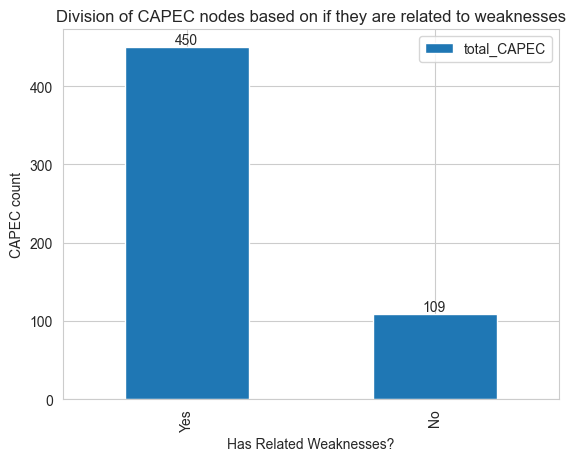

In [ ]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexRelatedWeaknesses IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_RelatedWeaknesses
ORDER BY total_CAPEC DESC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_RelatedWeaknesses', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on if they are related to weaknesses')
plt.xlabel('Has Related Weaknesses?')
plt.ylabel('CAPEC count')
plt.show()

Oftentimes attack patterns require a specific skill level for someone to execute it. ucoexSkills_Required gives a ranking of how much knowledge is needed to execute the attack and a desctiption of how its done in an array value. This value may also be null

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CAPEC Skill_Level
0          265        None
1          113        Low 
2           94     Medium 
3           87       High 


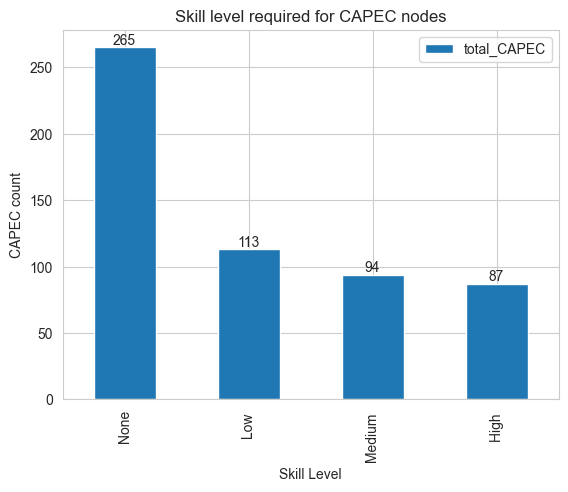

In [ ]:
query = """MATCH (n:UcoexCAPEC) 
RETURN count(DISTINCT n) as total_CAPEC, split(n.ucoexSkills_Required[0], [':', '-'])[1] as Skill_Level
ORDER BY total_CAPEC DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Skill_Level', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Skill level required for CAPEC nodes')
plt.xlabel('Skill Level')
plt.ylabel('CAPEC count')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


    Total  Year
0      39  1999
1       6  2000
2      19  2001
3      37  2002
4      52  2003
5      63  2004
6     143  2005
7     151  2006
8     122  2007
9     173  2008
10    144  2009
11    197  2010
12    278  2011
13    502  2012
14    648  2013
15    598  2014
16    709  2015
17   1308  2016
18   2485  2017
19   1803  2018
20   1590  2019
21   2420  2020
22   3035  2021
23  17808  2022
24  28329  2023
25  35681  2024
26  20761  2025


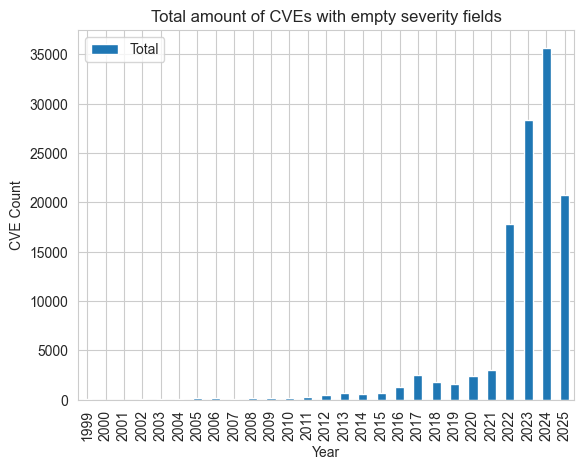

In [ ]:
#runs a query collecting all of the CVE nodes that are connected to CPE nodes through the UCOEXHASCPE relationship
query = """
MATCH (n:UcoCVE)
WHERE n.ucobaseSeverity = ""
RETURN count(DISTINCT n) as Total, split(n.label, '-')[1] as Year
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

df.plot(x='Year', y='Total', kind='bar')
plt.title('Total amount of CVEs with empty severity fields')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()

In [ ]:
#preparing to make graphs analyzing the data
#run a query to make a data frame that matches the CVEs related to UcoexCPE by UCOEXHASCPE
#will grab the following:
#CVE Label
#Year it was reported
#Severity Ranking
#Application affected
#null values and duplicates will be excluded from this query but NULL and EMPTY values will be examined later

query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucobaseSeverity <> ""
RETURN DISTINCT n.label as ID,split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity, split(c.cpeName, ':')[3] as Organization
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,ID,Year,Severity,Organization
0,CVE-1999-1029,1999,HIGH,ssh
1,CVE-1999-1055,1999,HIGH,microsoft
2,CVE-1999-1077,1999,MEDIUM,apple
3,CVE-1999-1066,1999,MEDIUM,sgi
4,CVE-1999-1083,1999,MEDIUM,t._hauck
...,...,...,...,...
216373,CVE-2025-5896,2025,MEDIUM,taro
216374,CVE-2025-5895,2025,MEDIUM,metabase
216375,CVE-2025-5881,2025,MEDIUM,fabianros
216376,CVE-2025-5887,2025,MEDIUM,jsnjfz


The chart excludes the CVE's that are not connected to CPE nodes. CVEs take a while to be connected to a CPE, so the results are likely to differ greatly from 2021

Year
1999     1509
2000     1265
2001     1598
2002     2427
2003     1553
2004     2882
2005     4737
2006     7066
2007     6645
2008     7242
2009     5196
2010     5543
2011     5044
2012     6167
2013     7143
2014     9939
2015     9983
2016    11638
2017    16569
2018    19238
2019    19440
2020    22426
2021    23459
2022    10282
2023     1524
2024     2767
2025     3096
Name: count, dtype: int64


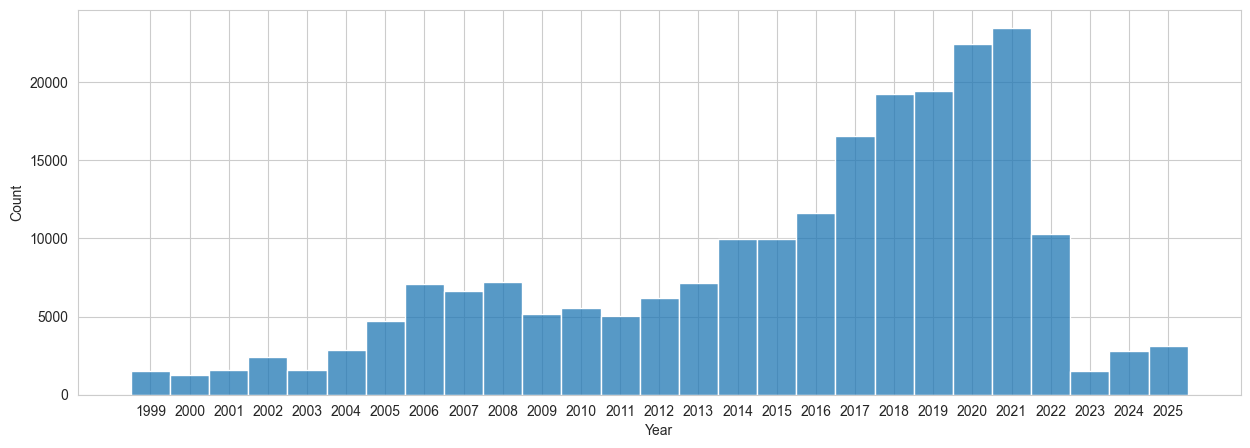

In [ ]:
#taking that dataframe, the first analysis done is to see how many vulnerabilities were
#reported by CVEs each year
#creating a bar graph to display the number of instances for each year
year_count = df['Year'].value_counts().sort_index()
print(year_count)

graph = sb.histplot(df, x='Year')
graph.figure.set_size_inches(15, 5)

Severity
LOW        22535
HIGH       65762
MEDIUM    128081
Name: count, dtype: int64


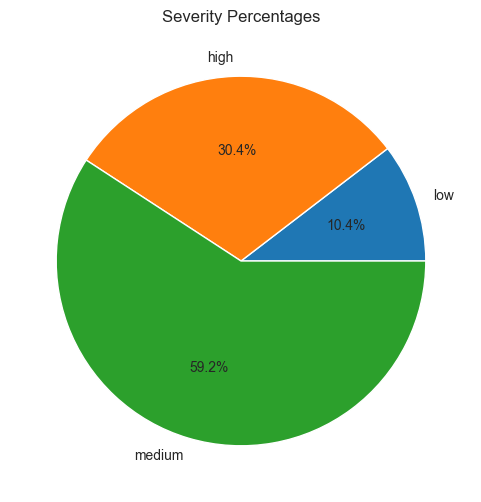

In [ ]:
#next we will look at the severity ranking of the overall data.
#the rankings are as follows: low, medium, and high
#create a graph that displays a count of all of the CVEs showing the percentages
Severity_count = df['Severity'].value_counts().sort_values(ascending=True)
print(Severity_count)

sb.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(Severity_count, labels=['low', 'high', 'medium'], autopct='%1.1f%%')
plt.title('Severity Percentages')
plt.show()

Give a CVE Counts per year by Severity as a bar chart

In [ ]:
#count how many distinct applications were affected
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE split(c.cpeName, ':')[3] IS NOT NULL AND n.ucobaseSeverity <> "" 
RETURN count(DISTINCT split(c.cpeName, ':')[3]) as Application_affected, split(n.label, '-')[1] as Year
ORDER BY split(n.label, '-')[1]
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df




C:\Users\peyto\AppData\Local\Temp\ipykernel_39004\659216814.py:5: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Application_affected,Year
0,343,1999
1,412,2000
2,575,2001
3,855,2002
4,620,2003
5,993,2004
6,1725,2005
7,2725,2006
8,2594,2007
9,2656,2008
